# Customer Churn Analysis
**Author:** Caroline Borges  
**Dataset:** IBM Telco Customer Churn ([Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn))  
**Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

## Business Context

In subscription-based businesses, retaining existing customers is significantly more cost-effective than acquiring new ones. Studies suggest that acquiring a new customer can cost **5x more** than retaining an existing one.

This analysis identifies behavioral and contractual patterns that predict customer churn, enabling data-driven retention strategies.

**Goal:** Understand *who* churns, *why*, and *what* the business can do about it.

| Detail | Info |
|---|---|
| Records | 7,043 customers |
| Features | 21 columns |
| Target variable | `Churn` (Yes / No) |
| Time scope | Single snapshot (last month) |

---

## Project Structure

```
1. Setup & Data Loading
2. ETL — Data Cleaning & Preparation   ← current section
3. Exploratory Data Analysis (EDA)
4. Churn Analysis by Customer Profile
5. Churn Analysis by Services
6. Churn Analysis by Contract & Financials
7. Business Conclusions & Recommendations
```

---
## 1. Setup & Data Loading

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [163]:
base = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
base.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 2. ETL — Data Cleaning & Preparation

Before any analysis, we need to ensure the data is reliable. This section covers:
- Column types inspection
- Null and blank value detection
- Duplicate records check
- Data type corrections
- Feature engineering

### 2.1 Initial Inspection

Using `info()` to get an overview of column types, non-null counts, and memory usage.

In [164]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

> **Finding:** `TotalCharges` is typed as `object` (string) instead of `float64`. 
> This is a red flag — financial columns should always be numeric. This suggests hidden blank values that prevented automatic type inference.

In [165]:
base['TotalCharges'].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.9       8
20.05      8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6531, dtype: int64

### 2.2 Investigating `TotalCharges`

Checking for blank strings disguised as valid values — these are invisible to `isnull()` but break numeric operations.

In [166]:
base[base['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


> **Root cause identified:** All 11 records with blank `TotalCharges` have `tenure = 0` — they are brand new customers who have not been billed yet.  
> **Decision:** Fill with `0` (not drop, not mean-impute), since these customers genuinely have no accumulated charges.

### 2.3 Fixing `TotalCharges` — Convert to Numeric

In [167]:
base['TotalCharges'] = pd.to_numeric(base['TotalCharges'], errors='coerce')

In [168]:
base['TotalCharges'] = base['TotalCharges'].fillna(0)

### 2.4 Checking for Duplicate Records

In [169]:
base.duplicated().sum()

np.int64(0)

> **Result:** No duplicate records found. Dataset integrity confirmed.

### 2.5 Fixing `SeniorCitizen` — Convert to Categorical

`SeniorCitizen` was encoded as `int64` (0/1), but it represents a category. Converting to `Yes`/`No` for consistency with other categorical columns.

In [170]:
base['SeniorCitizen'] = base['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [171]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   str    
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [172]:
base['churn_flag'] = base['Churn'].map({'No': 0, 'Yes': 1})

### 2.7 ETL Summary

| Step | Action | Result |
|---|---|---|
| Type inspection | `df.info()` | Identified `TotalCharges` as string |
| Blank detection | Filter `== ' '` | Found 11 records (tenure = 0) |
| Type fix | `pd.to_numeric` + `fillna(0)` | `TotalCharges` now `float64` |
| Duplicates | `duplicated().sum()` | 0 duplicates found |
| Categorical fix | `.map()` on `SeniorCitizen` | Converted 0/1 → No/Yes |
| Feature engineering | `.map()` on `Churn` | Created `churn_flag` (0/1) |

**Dataset ready for analysis:** 7,043 rows × 22 columns, fully typed and clean.

## EDA

#### Analysing clients who churned vs the ones who didn't to begin to understand patterns

In [173]:
total_clients = base['customerID'].value_counts().sum()

total_churn = base['churn_flag'].value_counts()[1]

perc_churn = (total_churn / total_clients) * 100

total_not_churn = base['churn_flag'].value_counts()[0]

perc_not_churn = (total_not_churn / total_clients) * 100

print(f"Total customers:   {total_clients}")
print(f"Total churned:     {total_churn} ({perc_churn:.1f}%)")
print(f"Total not churned: {total_not_churn} ({perc_not_churn:.1f}%)")

Total customers:   7043
Total churned:     1869 (26.5%)
Total not churned: 5174 (73.5%)


#### Analysing the risked revenue from clients who churned

In [174]:
monthly_churned_revenue = base[base['churn_flag'] == 1]['MonthlyCharges'].sum()

yearly_churned_revenue = monthly_churned_revenue * 12

print(f"Monthly revenue lost due to churn: ${monthly_churned_revenue:.2f} and yearly revenue lost: ${yearly_churned_revenue:.2f}")


Monthly revenue lost due to churn: $139130.85 and yearly revenue lost: $1669570.20


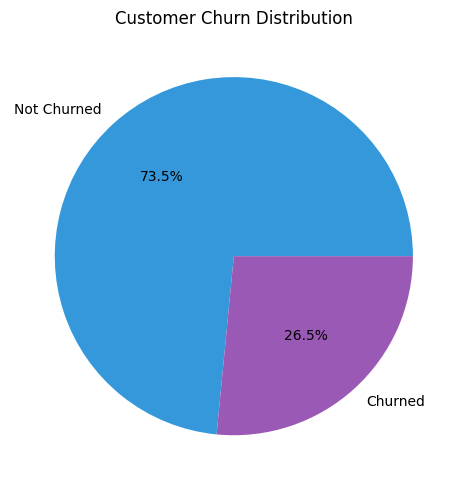

In [179]:
plt.figure(figsize=(5,5))
plt.pie(base['churn_flag'].value_counts(),labels=['Not Churned', 'Churned'], autopct='%1.1f%%', colors=['#3498db', '#9b59b6'])
plt.title('Customer Churn Distribution')
plt.tight_layout()
plt.show()

### 3.1 Tenure Analysis — Churned vs Retained Customers

We start by calculating the **mean tenure** for each group as an initial reference point.

In [180]:
mean_tenure_churned = base[base['churn_flag'] == 1]['tenure'].mean()

mean_tenure_not_churned = base[base['churn_flag'] == 0]['tenure'].mean()

print(f"Average tenure of churned customers: {mean_tenure_churned:.2f} months. Meanwhile, the average tenure of non-churned customers is {mean_tenure_not_churned:.2f} months.")

Average tenure of churned customers: 17.98 months. Meanwhile, the average tenure of non-churned customers is 37.57 months.


However, mean alone can be misleading in skewed distributions. A single long-tenured 
customer (e.g., 72 months) can pull the average up, masking the real behavior of the majority.

To validate, we ran `describe()` and found:
- **High standard deviation (19.5)** relative to the mean (17.98) — confirms skewness
- **Median tenure of churned customers: 10 months** — much lower than the mean

In [181]:
base[base['churn_flag'] == 1]['tenure'].describe()

count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: tenure, dtype: float64

**Conclusion:** Median is a more robust metric here. Most customers who churn leave 
within the first 10 months, which seems to be a classic early churn pattern.

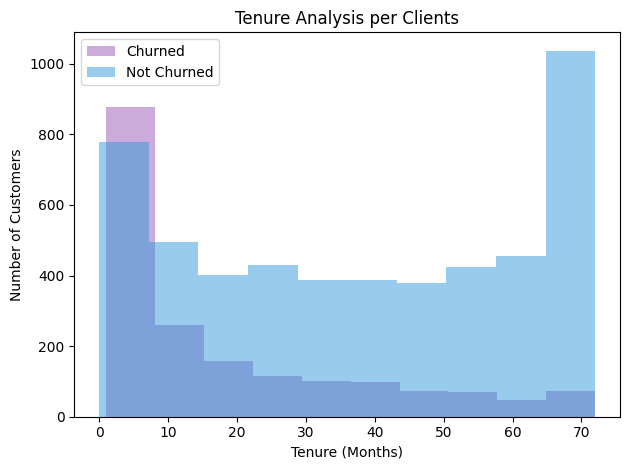

In [182]:
plt.hist(base[base['churn_flag'] == 1]['tenure'], alpha=0.5, color = '#9b59b6', label= "Churned")
plt.hist(base[base['churn_flag'] == 0]['tenure'], alpha=0.5, color = '#3498db', label= "Not Churned")
plt.title('Tenure Analysis per Clients')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()


A partir do histograma, vemos a relação entre o tempo de contrato e a quantidade de clientes, verificando que os clientes de 0 a 10 meses realmente tendem a churnar mais, representando quase 900 clientes.

### 3.2 Tenure Analysis — Churned vs Contract

Para analisar a relação entre os contratos assinados e churn, primeiro vamos calcular a taxa de churn para termos uma medida mais assertiva

In [195]:
mean_contract_churned = base.groupby('Contract')['churn_flag'].mean() * 100
print(mean_contract_churned.round(1).astype(str) + '%')

Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: churn_flag, dtype: str


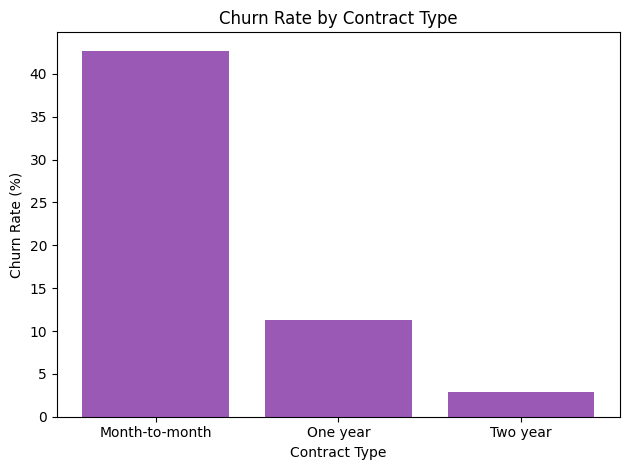

In [204]:
plt.bar(mean_contract_churned.index, mean_contract_churned, color = '#9b59b6')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show()